In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
print(df.isnull().sum())
df.dropna(inplace=True)

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [7]:
categorical = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
numerical = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
target = 'Delivery_Time_min'
X = df[categorical + numerical]
y = df[target]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical),
        ('num', StandardScaler(), numerical)
])
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [13]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Weather', 'Traffic_Level',
                                                   'Time_of_Day',
                                                   'Vehicle_Type']),
                                                 ('num', StandardScaler(),
                                                  ['Distance_km',
                                                   'Preparation_Time_min',
                                                   'Courier_Experience_yrs'])])),
                ('regressor', LinearRegression())])

In [15]:
y_pred = model.predict(X_test)
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 5.319617041145199
Mean Squared Error (MSE): 68.44776976091613
Root Mean Squared Error (RMSE): 8.273316732781124
R² Score: 0.8325314582304298


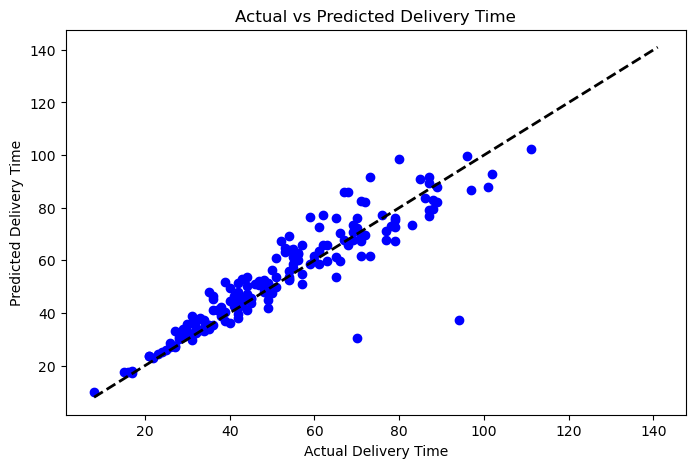

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

In [19]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sample training function (to be run once before deployment)
@st.cache_resource
def train_model():
    df = pd.read_csv("Food_Delivery_Times.csv")
    df.dropna(inplace=True)

    categorical = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
    numerical = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
    target = 'Delivery_Time_min'

    X = df[categorical + numerical]
    y = df[target]

    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), categorical),
        ('num', StandardScaler(), numerical)
    ])

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', LinearRegression())
    ])

    pipeline.fit(X, y)
    return pipeline, categorical, numerical

model, categorical_cols, numerical_cols = train_model()

# Streamlit App Layout
st.title("🚴‍♂️ Food Delivery Time Predictor")
st.markdown("### Enter delivery details below:")

# Input form
weather = st.selectbox("Weather Condition", ["Clear", "Rainy", "Foggy", "Stormy", "Windy"])
traffic = st.selectbox("Traffic Level", ["Low", "Medium", "High"])
time_of_day = st.selectbox("Time of Day", ["Morning", "Afternoon", "Evening", "Night"])
vehicle = st.selectbox("Vehicle Type", ["Bike", "Scooter", "Car"])
distance = st.slider("Distance (km)", 0.5, 30.0, 5.0)
prep_time = st.slider("Preparation Time (min)", 1, 60, 15)
experience = st.slider("Courier Experience (years)", 0.0, 10.0, 2.0)

# Predict button
if st.button("Predict Delivery Time"):
    input_df = pd.DataFrame([{
        "Weather": weather,
        "Traffic_Level": traffic,
        "Time_of_Day": time_of_day,
        "Vehicle_Type": vehicle,
        "Distance_km": distance,
        "Preparation_Time_min": prep_time,
        "Courier_Experience_yrs": experience
    }])

    prediction = model.predict(input_df)[0]
    st.success(f"🍔 Your food will arrive in approximately **{prediction:.2f} minutes**! Enjoy! 🎉")


2025-05-30 18:23:44.903 
  command:

    streamlit run C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
